# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [8]:
# Importar librerías necesarias
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [6]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [7]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [ ]:
"""
Ejemplo de la diferencia conceptual:
- LabelEncoder en 'sex': 'male' -> 1, 'female' -> 0 (todo en una columna).
- OneHotEncoder en 'sex': Crea 'sex_male' y 'sex_female' (dos columnas con 1s y 0s).
"""

### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

/tmp/ipykernel_36776/1398502477.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='sex', ax=axes[0], palette='pastel')
/tmp/ipykernel_36776/1398502477.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='sex_label', ax=axes[1], palette='pastel')


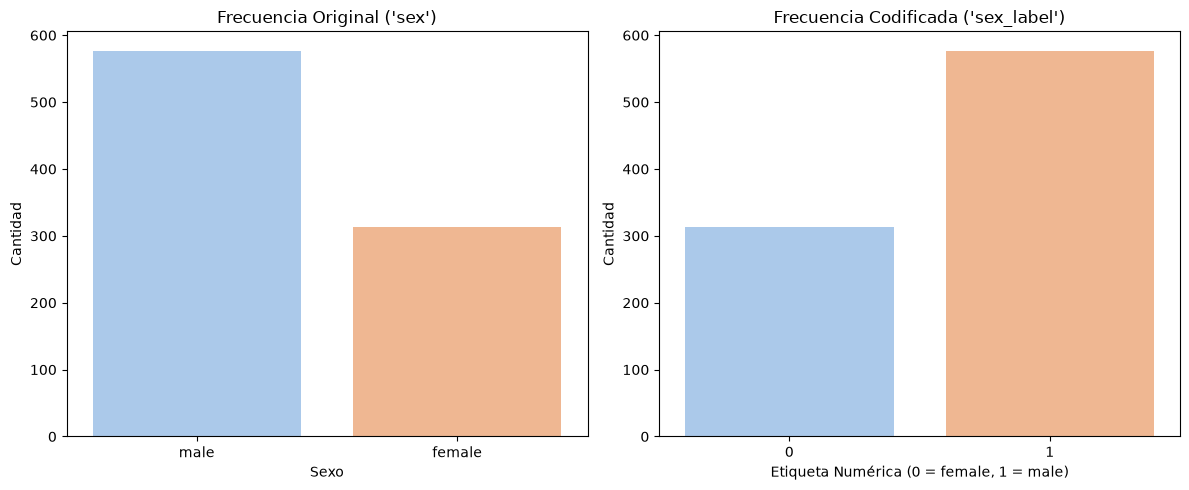

In [9]:
# Configurar la figura para mostrar dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Frecuencias de la variable original categórica
sns.countplot(data=data, x='sex', ax=axes[0], palette='pastel')
axes[0].set_title("Frecuencia Original ('sex')")
axes[0].set_xlabel("Sexo")
axes[0].set_ylabel("Cantidad")

# Gráfico 2: Frecuencias de la variable codificada
sns.countplot(data=data, x='sex_label', ax=axes[1], palette='pastel')
axes[1].set_title("Frecuencia Codificada ('sex_label')")
axes[1].set_xlabel("Etiqueta Numérica (0 = female, 1 = male)")
axes[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [10]:
# Aplicar codificación One Hot a la columna 'class'
onehot_class = pd.get_dummies(data['class'], prefix='class', dtype=int)

# Unir las nuevas columnas al dataframe original
data = pd.concat([data, onehot_class], axis=1)

# Mostrar el resultado
display(data[['class', 'class_First', 'class_Second', 'class_Third']].head())

"""
Ventaja:
Si usáramos LabelEncoder (ej. First=1, Second=2, Third=3), el modelo de aprendizaje 
automático podría asumir erróneamente que "Third" es matemáticamente el triple 
de importante que "First", introduciendo sesgos indeseados. Al usar OneHotEncoder 
y separar las variables con 0 y 1, prevenimos estas suposiciones numéricas.
"""

,class,class_First,class_Second,class_Third
0,Third,0,0,1
1,First,1,0,0
2,Third,0,0,1
3,First,1,0,0
4,Third,0,0,1


'\nVentaja:\nSi usáramos LabelEncoder (ej. First=1, Second=2, Third=3), el modelo de aprendizaje \nautomático podría asumir erróneamente que "Third" es matemáticamente el triple \nde importante que "First", introduciendo sesgos indeseados. Al usar OneHotEncoder \ny separar las variables con 0 y 1, prevenimos estas suposiciones numéricas.\n'

### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [ ]:
"""
1. OneHotEncoder (pd.get_dummies): Lo utilizaría para variables nominales (sin un 
   orden o jerarquía intrínseca), como la ciudad de embarque ('embarked') o el color, 
   creando nuevas columnas con 1s y 0s para evitar que el modelo infiera jerarquías 
   falsas[cite: 1, 4].

2. LabelEncoder / OrdinalEncoder: Lo reservaría exclusivamente para variables ordinales, 
   donde sí existe un orden claro (por ejemplo, tallas como Chico, Mediano, Grande, 
   o niveles educativos). En el dataset del Titanic, 'class' tiene un orden lógico 
   (Primera, Segunda, Tercera), por lo que un OrdinalEncoder podría ser válido si 
   queremos conservar esa jerarquía para ciertos algoritmos basados en árboles, 
   aunque OneHot suele ser la apuesta más segura en modelos de distancia o regresión.
"""